In [3]:
import numpy as np
import plot_style
import matplotlib.pyplot as plt

plot_style.apply()

In [4]:
#The pricing equation can be written as:
#p_t = \delta p^e_{t+1} + \delta d^e_{t+1}$$
#where $p^e_{t+1}$ and $d^e_{t+1}$ are the expected price and dividend at time t+1, formed at time t.

#For the dividend process we assume the following law of motion
#d_{t+1} = d_t  \epsilon_{t+1} where log \epsilon_{t+1} \sim iid normal( 0 , \sigma^2)
#This implies that E_t[d_{t+1}] = d_t e^{\sigma^2/2} := a d_t
#Assuming rational expectations, we have E_t{P_{t+1} / p_t} = a which implies that
#p_t = \delta a / ( 1 - a \delta) d_t and in turns this implies that gross returns are given by
#R_{t+1} = p_{t+1}/ p_t =  \epsilon_{t+1} and log return is given by log R_{t+1} = log \epsilon_{t+1} meaning that their expected value is 0 and their variance is \sigma^2.
#We check this claim now.

In [151]:
T = 1000
sigma = 0.005
log_eps = np.random.normal(0, sigma, T)
D = np.cumprod(np.exp(log_eps))
delta = 0.8
a = np.exp(sigma**2 / 2)
P = (delta * a) / (1 - a * delta) * D
R = P[1:] / P[:-1]
log_R = np.log(R)
print("Mean log return: ", np.mean(log_R), " Expected: 0")
print("Variance log return: ", np.var(log_R), " Expected: ", sigma**2)


Mean log return:  8.423580054656268e-05  Expected: 0
Variance log return:  2.697106848833004e-05  Expected:  2.5e-05


In [152]:
#Now we consider an agent who does not have rational expectations and instead forms expectations using OLS on past data.
#They have a PLM for log returns of the form
#log R_{t+1} = \beta log x_{t} + u_{t+1}
#this implies that gross returns are lognormal and their expected value is given by
#E_t[R_{t+1}] = exp( \beta log x_t + \sigma_u^2 / 2 )
#where x_t is an observable variable that the agent uses to forecast returns.
#We assume that x_t follows a standard normal distribution and is independent of returns.
x = np.random.normal(0, 0.01, T)

#initialization at rational expectations + small noise
beta_0 = 0.01
S_1 = x[0] ** 2 #second moment matrix (scalar in this case)

#price 0 at rational expectations
P_0 = (delta * a) / (1 - a * delta) * D[0]

#initialize arrays
beta = np.zeros(T)
beta[0] = beta_0
P = np.zeros(T)
P[0] = P_0
S = np.zeros(T+1)
S[0] = S_1
S[1] = S_1

R_expected = np.zeros(T + 1)
R_actual = np.zeros(T)

#loop over time
for t in range(1, T):
    #compute the forecasted return t+1 (R_2 in the first iteration)
    R_expected[t+1] = np.exp(beta[t-1] * x[t] + sigma**2 / 2)
    #compute price using the pricing equation
    P[t] = (delta * a) / (1 - delta * R_expected[t+1]) * D[t]
    #compute realized return
    R_actual[t] = P[t] / P[t-1]

    # #update beta recursive least squares
    # beta[t] = beta[t-1] * t ** -1 * S[t] ** -1 * (R_actual[t] - beta[t-1] * x[t-1])

    #update beta with constant gain
    gamma = 0.01
    beta[t] = beta[t-1] + gamma * S[t] ** -1 * x[t-1] * (R_actual[t] - beta[t-1] * x[t-1])

    # #update second moment matrix with recursive least squares
    # S[t+1] = S[t] + (t+1) ** -1 * (x[t] ** 2 - S[t])

    #update second moment matrix with constant gain
    S[t+1] = S[t] + gamma * (x[t] ** 2 - S[t])

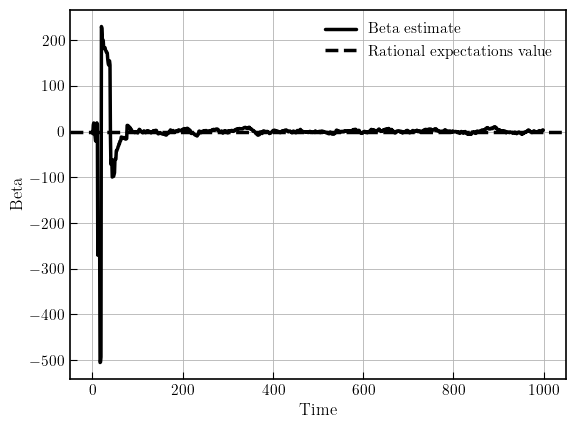

In [153]:
fig, ax = plt.subplots()
ax.plot(beta, label='Beta estimate')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
ax.legend()
plt.show()

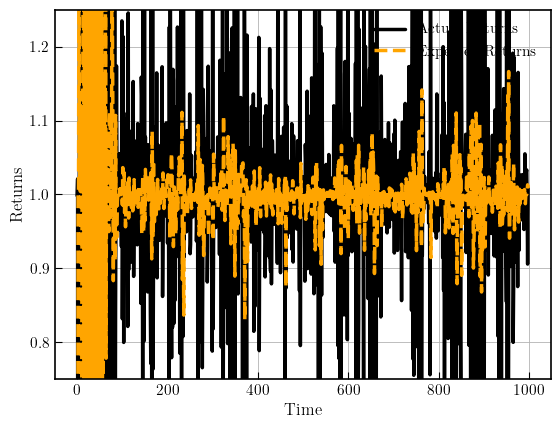

In [154]:
#visualize returns and expected returns, we need to shift R_expected by one period
fig, ax = plt.subplots()
ax.plot(R_actual[1:], label='Actual Returns')
ax.plot(R_expected[:-2], label='Expected Returns', linestyle='--', color = 'orange')
#set ylims 
ax.set_ylim(0.75, 1.25)
#ax.plot(np.exp(beta[:-1] * x[1:] + sigma**2 / 2), label='PLM Returns', linestyle=':', color = 'green')
ax.set_ylabel('Returns')
ax.set_xlabel('Time')
ax.legend()
plt.show()

In [155]:
# check if actual returns can be predicted by x_{t-1}
import statsmodels.api as sm

# Prepare the data
X = sm.add_constant(x[:T-1])  # Add a constant term for the intercept
y = R_actual[1:T]

# Fit the OLS model
model = sm.OLS(y, X).fit()

# Print the summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                 7.883e-05
Date:                Mon, 27 Oct 2025   Prob (F-statistic):              0.993
Time:                        16:15:20   Log-Likelihood:                -3308.5
No. Observations:                 999   AIC:                             6621.
Df Residuals:                     997   BIC:                             6631.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7052      0.210      3.354      0.0

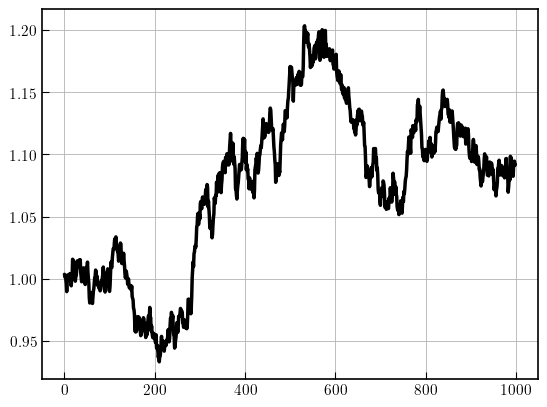

In [156]:
fig, ax = plt.subplots()
ax.plot(D, label='Price')

In [241]:
#Compute analytically the function COV( log R_{t+1} , x_t ) / VAR( x_t )
def analytical_cov(beta, sigma_x = 0.1, sigma_u = 0.1, delta = 0.8):
    
    #generate x as an ar(1) process
    x = np.random.normal(0, sigma_x, 10000)
    var_x = np.var(x)
    k = delta * np.exp(sigma_u ** 2 / 2)
    #first term
    term1 = np.log(1 - k * np.exp(beta * x[:-1]))
    #second term
    term2 = - np.log(1 - k * np.exp(beta * x[1:]))
    cov = np.cov(term1 + term2, x[:-1])[0, 1]

    #we also compute a first order approximation for small x
    
    cov_approx = - beta * k / (1 - k) * var_x
    return cov / var_x, cov_approx / var_x

In [277]:
x = np.random.normal(0, sigma_x, 10000)
x.max(), x.min()

(np.float64(0.20903900296431965), np.float64(-0.1865756134298326))

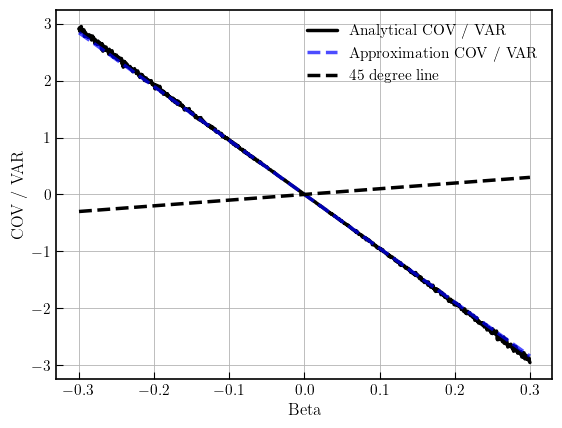

In [263]:
#Visualize for different values of beta in the range -0.5 to 0.5
beta_values = np.linspace(-0.3, 0.3, 1000)
sigma_x = 0.05
sigma_u = 0.1
delta = 0.9
cov_values = []
approx_cov_values = []
for b in beta_values:
    cov, cov_approx = analytical_cov(b, sigma_x, sigma_u, delta)
    cov_values.append(cov)
    approx_cov_values.append(cov_approx)


fig, ax = plt.subplots()
ax.plot(beta_values, cov_values, label='Analytical COV / VAR')

#show the approximation
ax.plot(beta_values, approx_cov_values, label='Approximation COV / VAR', linestyle='--', color= 'blue', alpha = 0.7)

#add the bisector
ax.plot(beta_values, beta_values, label='45 degree line', linestyle='--', color='black')
ax.set_xlabel('Beta')
ax.set_ylabel('COV / VAR')
ax.legend()
plt.show()

In [264]:
#check that beta_ols is still cov(x,y) / var(x) for x multivariate
x = np.random.normal(0, 1, (1000, 3))
beta_true = np.array([0.5, -0.2, 0.1])
y = x @ beta_true + np.random.normal(0, 0.1, 1000)
#compute beta_ols
beta_ols = np.linalg.inv(x.T @ x) @ (x.T @ y)
print("True beta: ", beta_true)
print("OLS beta: ", beta_ols)

#compute each coefficient as cov(x_i, y) / var(x_i)
beta_ols_check = np.array([np.cov(x[:, i], y)[0, 1] / np.var(x[:, i]) for i in range(x.shape[1])])  
print("OLS beta check: ", beta_ols_check)

True beta:  [ 0.5 -0.2  0.1]
OLS beta:  [ 0.50313514 -0.19458699  0.10030294]
OLS beta check:  [ 0.50430288 -0.20098965  0.10056067]


In [306]:
delta = 0.96
sigma_u = 0.01
delta * np.exp(sigma_u**2 / 2) * np.exp(0.01)

np.float64(0.9696966440209016)

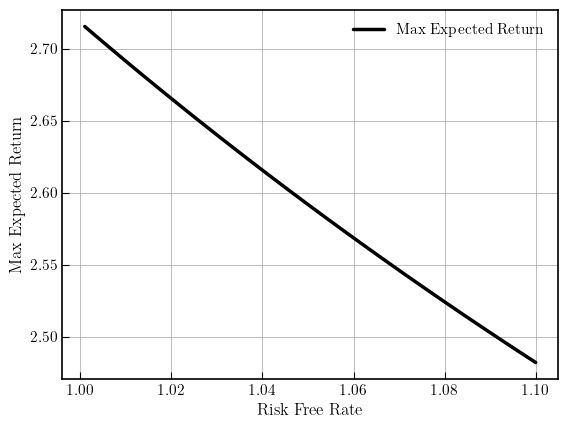

In [308]:
def max_expected_return(risk_free_rate):
    return np.exp(1/risk_free_rate)

r_free_grid = np.linspace(1.001, 1.1, 100)
max_returns = max_expected_return(r_free_grid)
fig, ax = plt.subplots()
ax.plot(r_free_grid, max_returns, label='Max Expected Return')
ax.set_xlabel('Risk Free Rate')
ax.set_ylabel('Max Expected Return')
ax.legend()
plt.show()

In [327]:
delta = 0.99
gamma = 5
a = 1.1
sigma_u = 0.1
kappa = delta * a ** (-gamma) * np.exp(sigma_u**2 / 2)
sigma_x = 0.01
sigma_d = 0.1
mean_d = sigma_d**2 / 2

T = 1000

seeds = np.arange(1, 31)
BETA = {}

for seed in seeds:
    np.random.seed(seed)
    #generate the x exogenous process
    x = np.random.normal(0, sigma_x, T)

    #generate the epsilon process (log epsilon for us)
    log_eps = np.random.normal(mean_d, sigma_d, T)

    #initial conditions (we need beta0, beta-1 S0, r0, x0 and x-1)
    r = np.zeros(T)
    beta = np.zeros(T)
    S = np.zeros(T)
    r[0] = log_eps[0]
    r[1] = log_eps[1]
    beta[0] = np.random.normal(0, 0.01)
    beta[1] = np.random.normal(0, 0.01)
    S[0] = x[0] ** 2
    S[1] = np.sum(x[:2] ** 2) / 2

    for t in range(2, T):
        beta[t] = beta[t-1] + t ** -1 * S[t-1] ** -1 * x[t-2] * (r[t-1] - beta[t-1] * x[t-2])
        S[t] = S[t-1] + (t+1) ** -1 * (x[t-1] ** 2 - S[t-1])
        r[t] = log_eps[t] - np.log(1 - kappa * np.exp(beta[t] * x[t])) + np.log(1 - kappa * np.exp(beta[t-1] * x[t-1]))

    BETA[seed] = beta


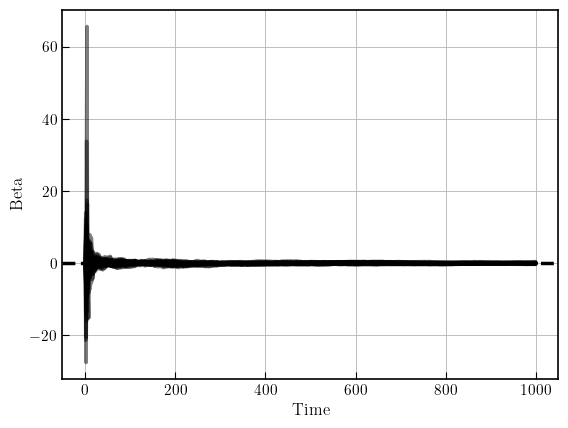

In [332]:
#Visualize all the betas across different seedsfig, ax = plt.subplots()
fig, ax = plt.subplots()
for i, beta in enumerate(BETA.values()):
    ax.plot(beta, label=f'Seed {seeds[i]}', alpha=0.5)
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
plt.show()

In [358]:
delta = 0.99
gamma = 5
a = 1.1
sigma_u = 0.1
kappa = delta * a ** (-gamma) * np.exp(sigma_u**2 / 2)
sigma_x = 0.01
sigma_d = 0.1
mean_d = sigma_d**2 / 2
alpha = 0.01 #constant gain

T = 10000

seeds = np.arange(1, 31)
BETA = {}

for seed in seeds:
    np.random.seed(seed)
    #generate the x exogenous process
    x = np.random.normal(0, sigma_x, T)

    #generate the epsilon process (log epsilon for us)
    log_eps = np.random.normal(mean_d, sigma_d, T)

    #initial conditions (we need beta0, beta-1 S0, r0, x0 and x-1)
    r = np.zeros(T)
    beta = np.zeros(T)
    S = np.zeros(T)
    r[0] = log_eps[0]
    r[1] = log_eps[1]
    beta[0] = np.random.normal(0, 0.01)
    beta[1] = np.random.normal(0, 0.01)
    S[0] = x[0] ** 2
    S[1] = np.sum(x[:2] ** 2) / 2

    for t in range(2, T):
        beta[t] = beta[t-1] + alpha * S[t-1] ** -1 * x[t-2] * (r[t-1] - beta[t-1] * x[t-2])
        S[t] = S[t-1] + alpha * (x[t-1] ** 2 - S[t-1])
        r[t] = log_eps[t] - np.log(1 - kappa * np.exp(beta[t] * x[t])) + np.log(1 - kappa * np.exp(beta[t-1] * x[t-1]))

    BETA[seed] = beta


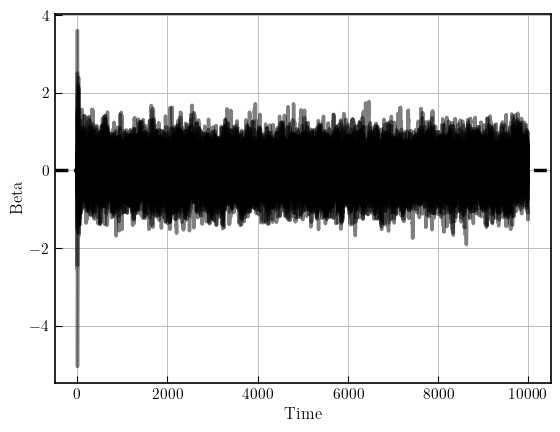

In [359]:
#visualize all the betas across different seedsfig, ax = plt.subplots()
fig, ax = plt.subplots()
for i, beta in enumerate(BETA.values()):
    ax.plot(beta, label=f'Seed {seeds[i]}', alpha=0.5)
ax.set_ylabel('Beta')
ax.set_xlabel('Time')
ax.axhline(0, color='black', linestyle='--', label='Rational expectations value')
plt.show()  

In [367]:
#theoretical variance
theoretical_variance = alpha * sigma_d**2 * (2 * sigma_x**2 * (1 + kappa / (1 - kappa) )) ** -1
theoretical_mean = 0

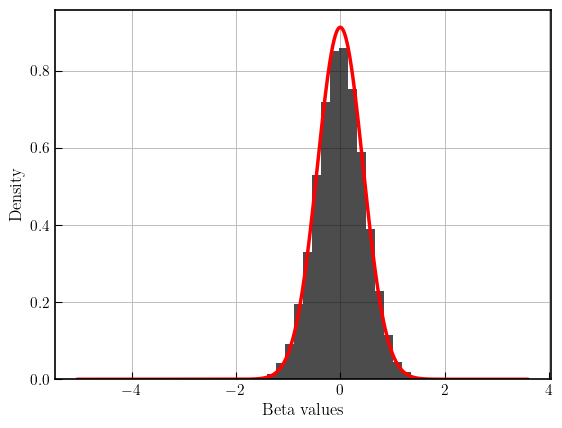

In [368]:
#plot an histogram of the betas, do not care about the seed now
fig, ax = plt.subplots()
all_betas = np.concatenate(list(BETA.values()))
ax.hist(all_betas, bins=50, density=True, alpha=0.7)
#overlay a normal distribution with theoretical mean and variance
from scipy.stats import norm
x_vals = np.linspace(all_betas.min(), all_betas.max(), 1000)
pdf_vals = norm.pdf(x_vals, loc=theoretical_mean, scale=np.sqrt(theoretical_variance))
ax.plot(x_vals, pdf_vals,  color='red')

ax.set_xlabel('Beta values')
ax.set_ylabel('Density')
plt.show()

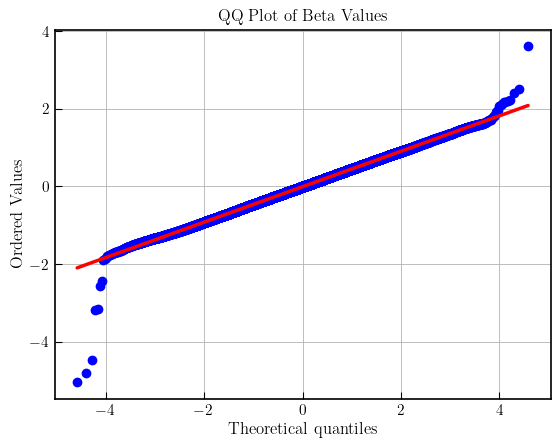

In [362]:
#QQ plot of the betas against the theoretical normal distribution
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
stats.probplot(all_betas, dist="norm", plot=ax)
ax.set_title('QQ Plot of Beta Values')
plt.show()

In [369]:
def weight(gamma, t):
    i = np.arange(t)
    weights = gamma * (1 - gamma) ** (t - i) 
    return weights

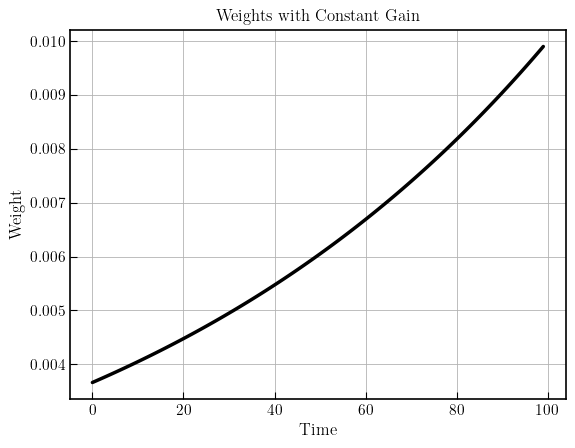

In [370]:
weights = weight(0.01, 100)
plt.plot(weights)
plt.title('Weights with Constant Gain')
plt.xlabel('Time')
plt.ylabel('Weight')
plt.show()

In [375]:
c = 0.99 #proportion of weights on first l observations
gamma = 0.1
l = int(np.log(1 - c) / np.log(1 - gamma))
print("Number of observations with 95% of the weight: ", l)

Number of observations with 95% of the weight:  43
